In [68]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
print(torch.__version__)

2.5.1+cu121


In [69]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [70]:
import pandas as pd
import torch

df = pd.read_csv(r'assignment2.csv')
# df = pd.read_csv(r'assignment-data.csv')
df.head(6)

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00
5,-8.8,543.08


In [71]:

X = torch.tensor(df['x'].values, dtype=torch.float32)
y = torch.tensor(df['y'].values, dtype=torch.float32)
print(f"X-Shape: {X.shape}")
print(f"y-Shape: {y.shape}")

X-Shape: torch.Size([99])
y-Shape: torch.Size([99])


In [72]:
!pip install scikit-learn

In [73]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([69]), torch.Size([69]), torch.Size([30]), torch.Size([30]))

In [74]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(79, 79, 20, 20)

In [75]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

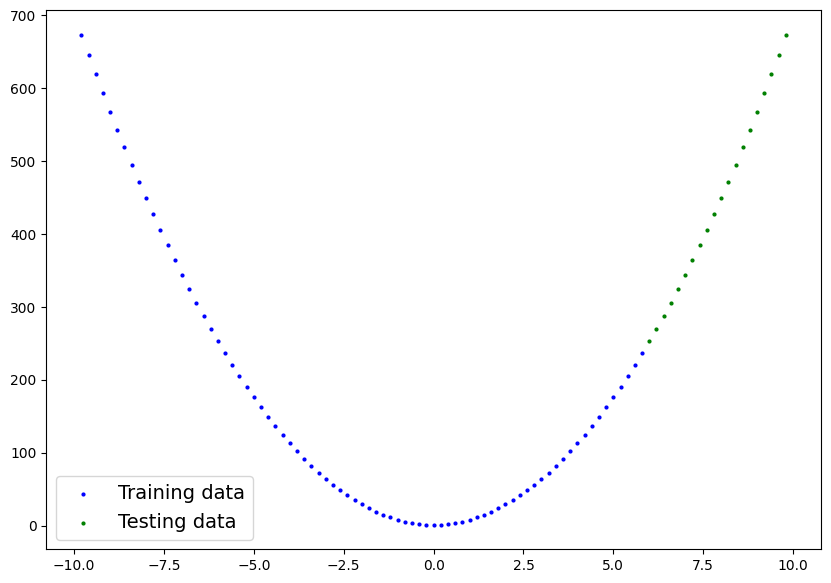

In [76]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

In [77]:

import torch.nn as nn

# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                    dtype=torch.float), # <- PyTorch loves float32 by default
                                    requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x  + self.bias + (3*x)**2 # <- Corrected to a standard linear regression formula (y = mx + b)

In [78]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

In [79]:

print(model_0.weights)
print(model_0.bias)

Parameter containing:
tensor([0.3367], requires_grad=True)
Parameter containing:
tensor([0.1288], requires_grad=True)


In [80]:

# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds[:5]

tensor([326.1490, 348.1762, 370.9236, 394.3909, 418.5784])

In [81]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 20
Number of predictions made: 20
Predicted values:
tensor([326.1490, 348.1762, 370.9236, 394.3909, 418.5784, 443.4857, 469.1129,
        495.4604, 522.5276, 550.3151, 578.8223, 608.0496, 637.9969, 668.6644,
        700.0518, 732.1590, 764.9863, 798.5336, 832.8011, 867.7885])


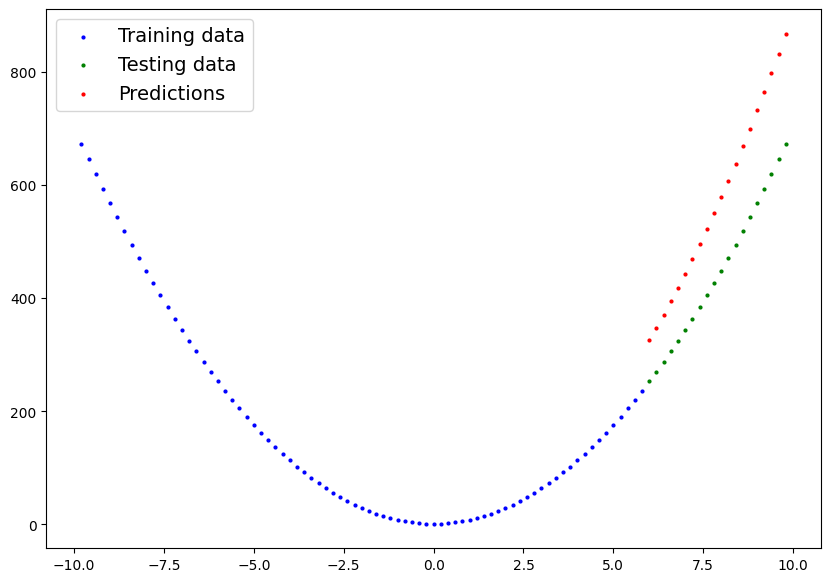

In [82]:
plot_predictions(predictions=y_preds)

In [83]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))
     

In [84]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 20000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 48.154388427734375 | MAE Test Loss: 129.4169921875 
Epoch: 10 | MAE Train Loss: 47.693580627441406 | MAE Test Loss: 130.8934326171875 
Epoch: 20 | MAE Train Loss: 47.239933013916016 | MAE Test Loss: 132.36314392089844 
Epoch: 30 | MAE Train Loss: 46.788169860839844 | MAE Test Loss: 133.82937622070312 
Epoch: 40 | MAE Train Loss: 46.348506927490234 | MAE Test Loss: 135.28164672851562 
Epoch: 50 | MAE Train Loss: 45.90884780883789 | MAE Test Loss: 136.73390197753906 
Epoch: 60 | MAE Train Loss: 45.48347854614258 | MAE Test Loss: 138.1646728515625 
Epoch: 70 | MAE Train Loss: 45.05948257446289 | MAE Test Loss: 139.59544372558594 
Epoch: 80 | MAE Train Loss: 44.646522521972656 | MAE Test Loss: 141.00840759277344 
Epoch: 90 | MAE Train Loss: 44.23977279663086 | MAE Test Loss: 142.4137420654297 
Epoch: 100 | MAE Train Loss: 43.84065628051758 | MAE Test Loss: 143.8043212890625 
Epoch: 110 | MAE Train Loss: 43.45263671875 | MAE Test Loss: 145.18017578125 
Epoch: 120 

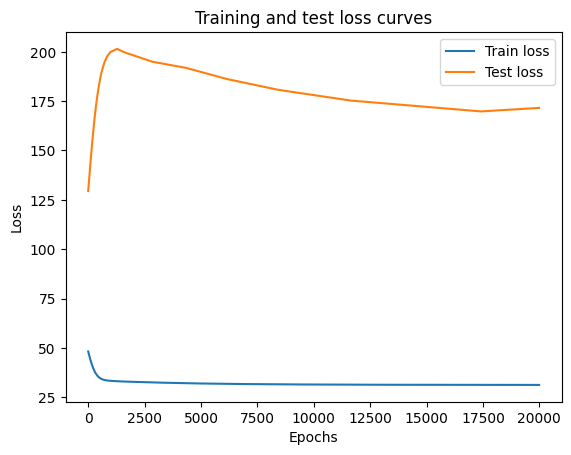

In [85]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();


In [86]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict([('weights', tensor([8.2929])), ('bias', tensor([-20.4074]))])

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


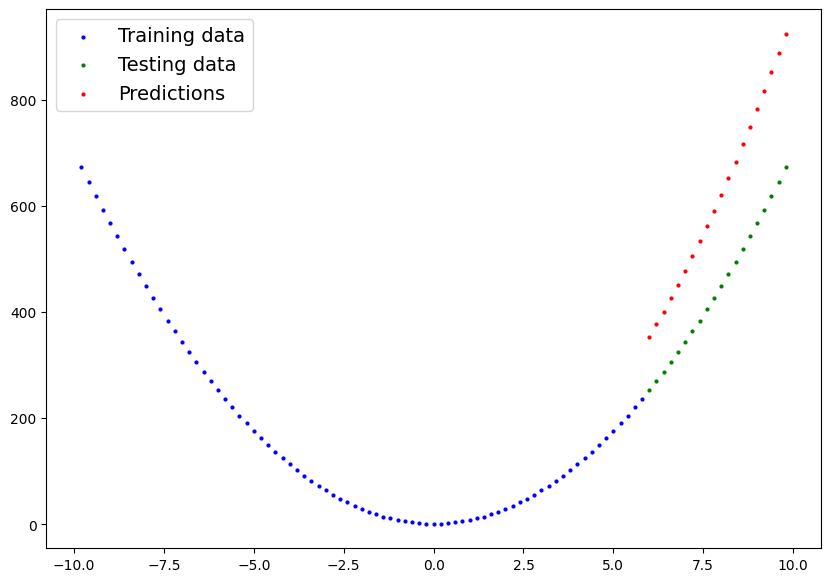

In [87]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)